<a href="https://colab.research.google.com/github/3ffeisullin/Exercises/blob/master/Fred_Feisullin_EmbeddedML_Assignment1_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---



Before starting, you must click on the "Copy To Drive" option in the top bar. Go to File --> Save a Copy to Drive. Name it *'LastName_FirstName_Assignment1.ipynb'*. <ins>This is the master notebook so you will not be able to save your changes without copying it !</ins> Once you click on that, make sure you are working on that version of the notebook so that your work is saved.



---



# 1. Regression using Single-Layer Neural Network

In the first section of the assignment you will design your own regression model for function **Y = wX + b** using TensorFlow.
We start by setting up the problem for you.

In [ ]:
# DO NOT CHANGE THIS CELL

# We first import TensorFlow and other libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# We define a callback function that populates 'predictions' with predicted ys for every epoch
predictions = []
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    predictions.append(model.predict(xs))
callbacks = myCallback()

# We then define the xs (inputs) and ys (outputs)
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

Let's understand the data. Plot and visualize the data (xs and ys).

***Hint***: Use plt.scatter()

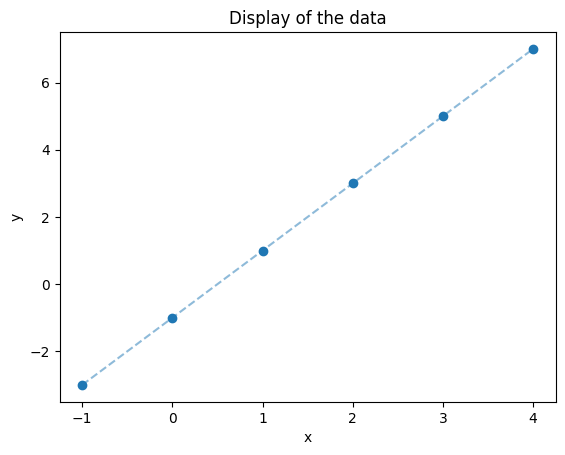

In [ ]:
# TODO: Visualize xs and ys
plt.scatter(xs, ys)
plt.plot(xs, ys, linestyle='--', alpha=0.5)  # the line connecting these points shows the trend
plt.xlabel('x')
plt.ylabel('y')
plt.title('Display of the data')
plt.show()


### Define Model

In the below cell, define your regression model - a single layer neural network with a dense layer - with appropriate shape, loss function and optimizer. You're free to choose the number of neuron units in the layer. Then compile the model.

In [ ]:
# TODO - Define Model and Compile it

from tensorflow.keras import Input

model = Sequential([
    Input(shape=[1]),
    Dense(units=1)
])

model.compile(optimizer='sgd', loss='mean_squared_error')


### Train Model

We then fit the trained model to the training data.

In [ ]:
# DO NOT CHANGE THIS CELL

# We then fit the model
epochs = 300
print("Training!")
model.fit(xs, ys, epochs=epochs, callbacks=[callbacks], verbose=2)

Training!
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 - 0s - 284ms/step - loss: 42.2172
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 - 0s - 94ms/step - loss: 33.5783
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 - 0s - 100ms/step - loss: 26.7741
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 - 0s - 106ms/step - loss: 21.4136
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 - 0s - 103ms/step - loss: 17.1890
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 - 0s - 99ms/step - loss: 13.8583
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 - 0s - 100ms/step - loss: 11.2310
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 - 0s - 101ms/step - loss: 9.1572
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 - 0s - 97ms/step - loss: 7.5191
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 - 0s - 95ms/step - loss: 6.2238
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 - 0s - 115ms/step - loss: 5.1984
Epoch 12/300
1/1 ━━━━━━━━━━━

### Plot Loss graph

Use the ***predicted ys*** and the ***ground truth ys*** to manually calculate the MSE (mean-squared error) loss for each epoch. Then, plot the **loss vs epochs** graph, which should represent decreasing loss.

***Hint1:*** The shape of 'predictions' array is **(epochs, 6)** - this represents a 2D array of the 6 predicted Y values at every epoch. Each row represents the 6 predicted Y values.

***Hint2:*** Store the 'loss' as a 1D vector of size **(epochs)**. Each value will represent the MSE (of all 6 Ys) at each epoch.

Predictions array shape: (300, 6)
Ys Ground Truth shape:  (6,)


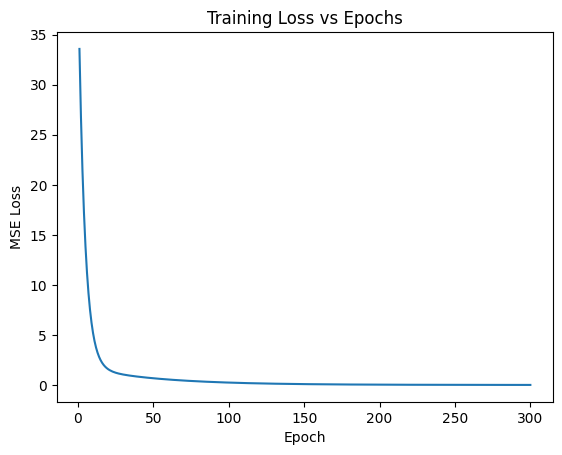

In [ ]:
predictions = np.asarray(predictions)
predictions = predictions.reshape(epochs, 6)
print("Predictions array shape:" ,predictions.shape)
print("Ys Ground Truth shape: ", ys.shape)

# TODO - Calculate MSE Loss and Plot Loss graph

# Manually calculate MSE loss for each epoch
loss = np.mean(np.square(predictions - ys), axis=1)  # shape: (epochs,)

# Plot loss vs epochs
plt.plot(range(1, epochs + 1), loss)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss vs Epochs')
plt.show()



Below is a plot of the resulting y predictions at EPOCH_NUMBERS = 1, 25, 50, 150, 300. If you'd like to see other predictions at other epochs, update the EPOCH_NUMBERS variable and re-run the cell!

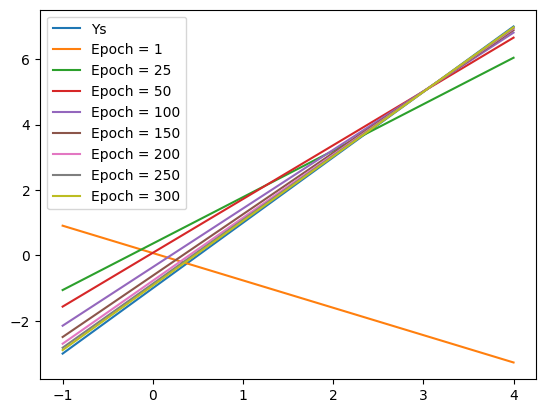

In [ ]:
EPOCH_NUMBERS=[1,25,50,100, 150,200, 250, 300] # Update me to see other Epochs
plt.plot(xs,ys,label = "Ys")
for EPOCH in EPOCH_NUMBERS:
    plt.plot(xs,predictions[EPOCH-1],label = "Epoch = " + str(EPOCH))
plt.legend()
plt.show()

# 2. Multiclass Classification using Dense Neural Network

In the second section of the assignment, you'll create a multi-layer Neural network with Dense layers for a Multi-class Classification problem.

We start by setting up the problem for you.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

You will be using the Fashion MNIST Dataset. - https://github.com/zalandoresearch/fashion-mnist. In the below cell, use the TensorFlow Keras API to load the datatset and split it into training and test sets.

In [ ]:
# TODO - Load in fashion MNIST

# Load the Fashion MNIST dataset and split into training and test sets
fashion_mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training images shape:", training_images.shape)
print("Training labels shape:", training_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


### Plot Sample Training Examples



---


Question 1: Plot the first 3 training images along with the training labels.



---



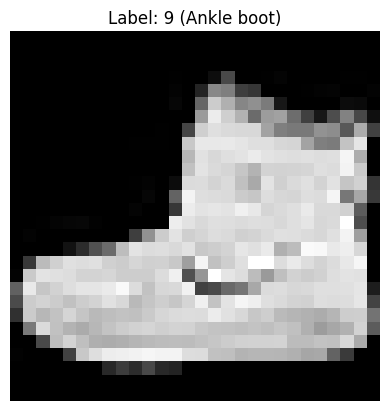

In [ ]:
# TODO - plot 1st training example

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.imshow(training_images[0], cmap='gray')  # Image 0: 28x28 grayscale pixel array
plt.title(f"Label: {training_labels[0]} ({class_names[training_labels[0]]})")  # Numeric label + class name
plt.axis('off')  # Hide axes since pixel coordinates aren't meaningful here
plt.show()

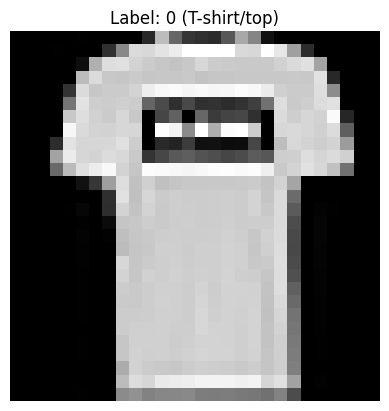

In [ ]:
# TODO - plot 2nd training example
plt.imshow(training_images[1], cmap='gray')  # Image 1: 28x28 grayscale pixel array
plt.title(f"Label: {training_labels[1]} ({class_names[training_labels[1]]})")  # Numeric label + class name
plt.axis('off')  # Hide axes since pixel coordinates aren't meaningful here
plt.show()


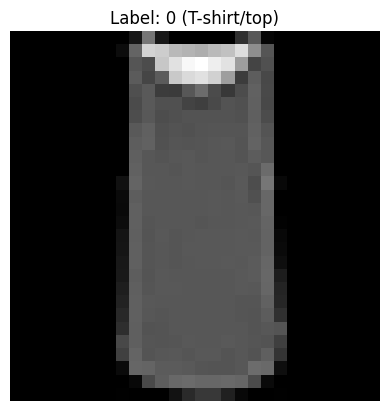

In [ ]:
# TODO - plot 3rd training example
plt.imshow(training_images[2], cmap='gray')  # Image 2: 28x28 grayscale pixel array
plt.title(f"Label: {training_labels[2]} ({class_names[training_labels[2]]})")  # Numeric label + class name
plt.axis('off')  # Hide axes since pixel coordinates aren't meaningful here
plt.show()


### Define Model

We define the below model - a two-layer DNN (one hidden layer, output layer) - to take in the Fashion MNIST 28 x 28 grayscale image as input. This is in addition to the input layer. Can you detetrmine the number of neurons in the output layer?

In [ ]:
# Define the base model

No_Output_Neurons = 10 # < YOUR ANSWER HERE > #
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28,28)),
                                    tf.keras.layers.Dense(512, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(No_Output_Neurons, activation=tf.nn.softmax)])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In the below cell, compile the above defined model with the appropriate Optimizer and Loss Function. Use accuracy as your metric.

Refer to the TensorFlow Documentation!

In [ ]:
# TODO - compile the model

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Train Model

Next, we fit the trained model to the training set. But before we do that, we must **preprocess our training and test images**!!

Neural Networks learn the best when the data is scaled / normalized to fall in a constant range. Practitioners often use the range [0,1]. How might you do this to the training and test images used here?

*A hint: these images are saved in the standard [RGB](https://www.rapidtables.com/web/color/RGB_Color.html) format*

In [ ]:
# TODO - Preprocess Training and Test Images
training_images = training_images / 255.0
test_images = test_images / 255.0


Using these improved images, we train the model! Since this is a very simple dataset we only train for 5 epochs.



---


**Question 2:** Train the model for epochs = 5, 15, 20 and report the accuracies.

**Answer:**


1.   epochs = 5, training accuracy =
2.   epochs = 15, training accuracy =
3.   epochs = 20, training accuracy = 94%





---

In [ ]:
# fit the model to the training data
print("training_images dtype:", training_images.dtype)
print("training_images shape:", training_images.shape)
print("training_images min/max:", training_images.min(), training_images.max())
print("training_labels dtype:", training_labels.dtype)
print("training_labels shape:", training_labels.shape)
print("training_labels unique values:", np.unique(training_labels))
print("Training!")
model.fit(training_images, training_labels, epochs=20)

training_images dtype: float64
training_images shape: (60000, 28, 28)
training_images min/max: 0.0 1.0
training_labels dtype: uint8
training_labels shape: (60000,)
training_labels unique values: [0 1 2 3 4 5 6 7 8 9]
Training!
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8303 - loss: 0.4772
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8671 - loss: 0.3645
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8816 - loss: 0.3234
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8878 - loss: 0.3003
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8945 - loss: 0.2799
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9004 - loss: 0.2667
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9048 - loss: 0.2538
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9094 - loss: 0.2419
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accu

Once it's done training -- you should see an accuracy value at the end of the final epoch. It might look something like ~ 0.86 - 0.89 for epochs = 5. This tells you that your neural network is about 86 - 89% accurate in classifying the training data. i.e., it figured out a pattern match between the image and the labels that worked 86% - 89% of the time.

### Evaluate Model

How well would the model work with unseen data? That's why we have the test images. We can call ```model.evaluate```. It evaluates our model on the test images and compares the predictions to the actual test labels.

Refer TensorFlow Documentation to learn how to use the ```model.evaluate``` API.

In [16]:
# TODO - test the model on the test data

# Evaluate the trained model on the held-out test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

# Print the results
print(f"Test accuracy: {test_accuracy:.4f}")  # Proportion of test images correctly classified
print(f"Test loss: {test_loss:.4f}")          # Sparse categorical crossentropy loss on the test set


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8937 - loss: 0.3631
Test accuracy: 0.8937
Test loss: 0.3631


The API returns a loss value followed by the test accuracy. You might get an accuracy of around 87 - 89% accuracy. Not Bad!



But what did it actually learn? If we inference on the model using ```model.predict``` we get out the following list of values. **What does it represent?**

*A hint: trying running ```print(test_labels[0])```*

In [17]:
classifications = model.predict(test_images)
print("predictions:", classifications[0])    # probability distribution for predictions of first test image.
print("final prediction:", np.argmax(classifications[0]))      # final prediction - max probability
print("gound truth:", test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
predictions: [3.2166053e-15 4.8159303e-15 6.3044869e-16 4.6533847e-19 2.0310812e-14
 6.8657955e-06 1.2121162e-13 1.8466460e-04 7.0962264e-12 9.9980855e-01]
final prediction: 9
gound truth: 9


You can also visualize the results!

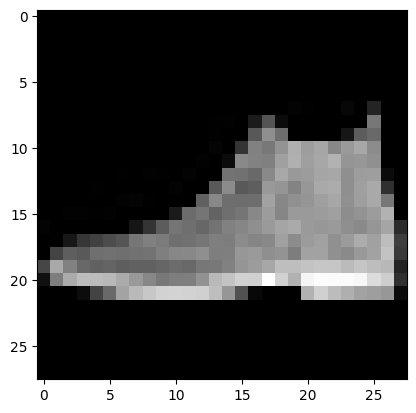

In [19]:
plt.imshow(test_images[0], cmap='gray')

### Case 1 - Double number of Neurons in Hidden Dense Layer

In the below cell, define a model with double the number of neurons in the dense hidden layer. Then, compile the model, train the model on the training set, and evaluate the model on the test set.



In [20]:
# TODO - Define model, compile, train, evaluate

# Define a new model with double the neurons in the hidden layer (1024 instead of 512)
No_Output_Neurons = 10
model_double = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),                                  # Flatten 28x28 image into a 784-length vector
    tf.keras.layers.Dense(1024, activation=tf.nn.relu),         # Hidden layer with double the neurons (512 -> 1024)
    tf.keras.layers.Dense(No_Output_Neurons, activation=tf.nn.softmax)  # Output layer: 10-class probability distribution
])

# Compile the model with the same optimizer, loss, and metric as before
model_double.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Train the model on the training set
print("Training!")
model_double.fit(training_images, training_labels, epochs=20)

# Evaluate the trained model on the test set
test_loss, test_accuracy = model_double.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

Training!
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8295 - loss: 0.4726
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8693 - loss: 0.3565
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8824 - loss: 0.3208
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8889 - loss: 0.2989
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8961 - loss: 0.2771
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9025 - loss: 0.2628
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9055 - loss: 0.2514
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9104 - loss: 0.2403
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9150 - loss: 0.2282
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9163 - loss: 0.2185
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9204 - loss: 0.2119
Epoc


Here are the results: 	512 neurons	1024 neurons
Training accuracy	94.16%	94.12%
Training loss	0.1563	0.1560
Time per epoch	~10-11s	~18s

Training performance is essentially identical — the tiny differences (94.16% vs 94.12%) are just noise from random weight initialization, not a meaningful effect of more neurons. Meanwhile, training time nearly doubled.

This shows that: more neurons in a single hidden layer doesn't automatically mean better performance. In this case, 512 neurons is already enough capacity to capture the patterns in Fashion MNIST that a single-hidden-layer Dense network can learn; adding more neurons just gives it more parameters to fit without any new complexity gained from the architecture itself, so both models plateau at a similar training accuracy.

---



**Question 3:** Do you observe a difference in loss, accuracy, training time etc and if so list them down. Why do you think that's the case?

**Answer**: See above.



---



### Case 2 - Include Additional Dense Layer

Consider the effects of additional layers in the network instead of just adding more neurons to the same layer.

In the below cell, define a model to add an additional layer with 128 neurons between the two existing Dense layers.

In [21]:
# TODO - Define Similar Model as before with additional Layer
# Define a model with an additional hidden layer (128 neurons) inserted between the existing two Dense layers
No_Output_Neurons = 10
model_deeper = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),                                   # Flatten 28x28 image into a 784-length vector
    tf.keras.layers.Dense(512, activation=tf.nn.relu),           # First hidden layer (original size)
    tf.keras.layers.Dense(128, activation=tf.nn.relu),           # New second hidden layer with 128 neurons
    tf.keras.layers.Dense(No_Output_Neurons, activation=tf.nn.softmax)  # Output layer: 10-class probability distribution
])

# Compile the model with the same optimizer, loss, and metric as before
model_deeper.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Train the model on the training set
print("Training!")
model_deeper.fit(training_images, training_labels, epochs=20)

# Evaluate the trained model on the test set
test_loss, test_accuracy = model_deeper.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

Training!
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8279 - loss: 0.4733
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8710 - loss: 0.3540
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8821 - loss: 0.3202
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8916 - loss: 0.2961
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8955 - loss: 0.2791
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9010 - loss: 0.2638
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9058 - loss: 0.2516
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9091 - loss: 0.2424
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9134 - loss: 0.2298
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9154 - loss: 0.2231
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9185 - loss: 0.2159
Epoch 12/

We then compile the model, fit the model to training data, and evaluate our model on the test data.

In [23]:
# TODO -# Compile the model with the same optimizer, loss, and metric as before
# Redefine the model fresh (so training starts from random weights, not the previous run's weights)
No_Output_Neurons = 10
model_deeper = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(No_Output_Neurons, activation=tf.nn.softmax)
])

# Compile the model with the same optimizer, loss, and metric as before
model_deeper.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Train the model on the training set
print("Training!")
model_deeper.fit(training_images, training_labels, epochs=20)

# Evaluate the trained model on the test set
test_loss, test_accuracy = model_deeper.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")



Training!
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8285 - loss: 0.4712
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8677 - loss: 0.3578
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8814 - loss: 0.3207
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8900 - loss: 0.2963
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8959 - loss: 0.2785
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9001 - loss: 0.2650
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9068 - loss: 0.2492
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9088 - loss: 0.2404
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9132 - loss: 0.2303
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9161 - loss: 0.2208
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9193 - loss: 0.2101
Epoch 12/

Model	Training accuracy	Training loss	Test accuracy	Test loss
512 neurons (1 hidden layer)	94.16%	0.1563	—	—
1024 neurons (1 hidden layer)	94.12%	0.1560	89.12%	0.3576
512 → 128 (2 hidden layers)	93.80%	0.1599	89.46%	0.3834

: neither widening the hidden layer (512→1024) nor adding depth (512→128→10) meaningfully improved performance on this dataset with Dense layers. This ~89% test accuracy appears to be a rough ceiling for this style of architecture on Fashion MNIST — breaking past it typically requires a different architecture altogether,
---



**Question 4:** What happens to the error? How does this compare to the original model and the model with double the number of neurons?

**Answer**:



---

Model	Training accuracy	Training loss	Test accuracy	Test loss
512 neurons (1 hidden layer)	94.16%	0.1563	—	—
1024 neurons (1 hidden layer)	94.12%	0.1560	89.12%	0.3576
512 → 128 (2 hidden layers)	93.87%	0.1604	89.09%	0.4040

Neither widening the hidden layer (512→1024) nor adding depth (512→128→10) meaningfully improved performance on this dataset with Dense layers. This ~89% test accuracy appears to be a rough ceiling for this style of architecture on Fashion MNIST — breaking past it typically requires a different architecture altogether,

# Callbacks

Sometimes if we set the model training for too many epochs we may find that training stops improving. In this case, it would be ideal to quit training early. TensorFlow has a function called ```Callbacks``` which can check the results from each epoch.

Below, we stop training the model when the accuracy is above 86%.

In [25]:
# define and instantiate your custom Callback
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if( logs.get('accuracy') > 0.86):
      self.model.stop_training = True


callbacks = myCallback()


In the below cell, re-compile the model, re-fit the model to the training data and re-evaluate the model on the test data! Observe that the training process is much shorter!

**Note:** When you train the model, refer to the myCallback() class object.


***Hint:*** Use the callbacks flag in the `model.fit()` API

In [ ]:
# TODO - re-compile, re-fit and re-evaluate

